# 01 — Exploration du jeu de données SonarQube FP

Objectifs :
- Vérifier `main_dataset.csv` : shape, distribution `cls`, règles `squid`
- Inspecter `data/input/` : format, dimensions, split train/test, distribution des labels
- Charger les métriques de référence de l'article via `best_10fold_metrics.pkl`
- Inspecter le modèle Word2Vec et comprendre la construction des 480 features

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

ROOT = '..'

---
## 1. `main_dataset.csv` — données brutes

In [2]:
df = pd.read_csv(f'{ROOT}/data/raw/main_dataset.csv')
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head(3)

Shape : (224484, 12)
Colonnes : ['squid', 'line_m2', 'line_m1', 'line_0', 'line_1', 'line_2', 'token_line_m2', 'token_line_m1', 'token_line_0', 'token_line_1', 'token_line_2', 'cls']


,squid,line_m2,line_m1,line_0,line_1,line_2,token_line_m2,token_line_m1,token_line_0,token_line_1,token_line_2,cls
0,squid_S1168,return blobCache.load(chunkKey).ge...,}\r\n,return null;\r\n,}\r\n,}\r\n,Keyword_return Identifier Separator Identifier...,Separator,Keyword_return Null Separator,Separator,Separator,0
1,squid_S1141,patchResourcewithSparql(resource()...,\r\n,try {\r\n,session.save();\r\n,} catch (final RepositoryException...,Identifier Separator Identifier Separator Sepa...,NaN,Keyword_try Separator,Identifier Separator Identifier Separator Sepa...,Separator Keyword_catch Separator Modifier_fin...,0
2,squid_S1141,private Node getFrozenNodeByLabel(final St...,try {\r\n,try {\r\n,final Node frozenNode = sessio...,\r\n,Modifier_private Identifier Identifier Separat...,Keyword_try Separator,Keyword_try Separator,Modifier_final Identifier Identifier Operator_...,NaN,0


In [3]:
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())

Valeurs manquantes par colonne :
squid                0
line_m2              0
line_m1              0
line_0               0
line_1               0
line_2               0
token_line_m2    33905
token_line_m1    51482
token_line_0        59
token_line_1     41299
token_line_2     29434
cls                  0
dtype: int64


### 1.1 Distribution de `cls`
- `cls = 0` → vrai positif SonarQube (bug réel)
- `cls = 1` → faux positif SonarQube (fausse alarme à filtrer)

cls=0 (TP/bug réel) :   47015  (20.9%)
cls=1 (FP/fausse alarme) :  177469  (79.1%)


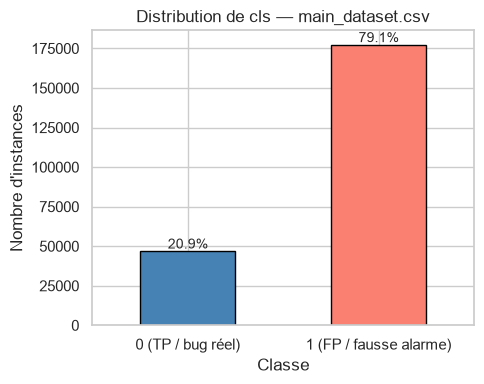

In [4]:
cls_counts = df['cls'].value_counts().sort_index()
n = len(df)
print(f'cls=0 (TP/bug réel) : {cls_counts[0]:>7}  ({cls_counts[0]/n:.1%})')
print(f'cls=1 (FP/fausse alarme) : {cls_counts[1]:>7}  ({cls_counts[1]/n:.1%})')

fig, ax = plt.subplots(figsize=(5, 4))
cls_counts.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black', width=0.5)
ax.set_title('Distribution de cls — main_dataset.csv')
ax.set_xlabel('Classe')
ax.set_ylabel('Nombre d\'instances')
ax.set_xticklabels(['0 (TP / bug réel)', '1 (FP / fausse alarme)'], rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{bar.get_height()/n:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 1.2 Distribution des règles SonarQube (`squid`)

In [5]:
squid_counts = df['squid'].value_counts()
print(f'Nombre de règles uniques : {df["squid"].nunique()}')
print(f'\nTop 10 règles les plus fréquentes :')
print(squid_counts.head(10))

Nombre de règles uniques : 160

Top 10 règles les plus fréquentes :
squid
squid_S2208                 60909
squid_S00115                27048
squid_S00100                16015
squid_S1166                 13388
squid_S2293                 11987
squid_UselessImportCheck     9763
squid_S00116                 9080
squid_S1214                  6683
squid_S106                   4907
squid_S1213                  4163
Name: count, dtype: int64


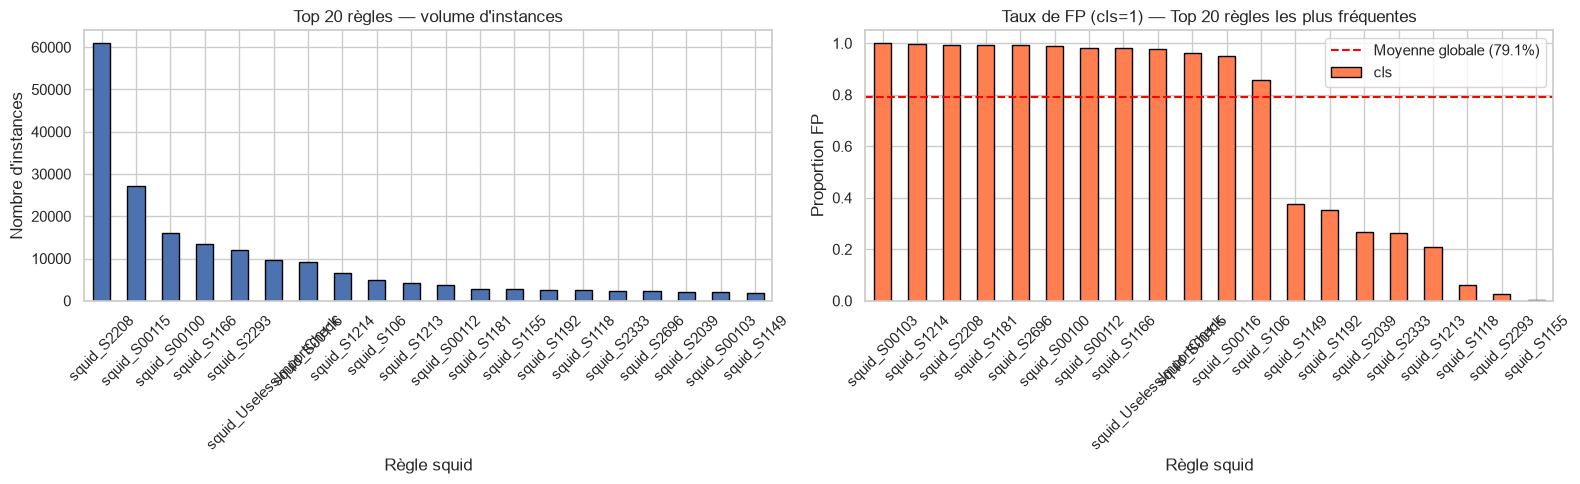

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 20 par volume
squid_counts.head(20).plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Top 20 règles — volume d\'instances')
axes[0].set_xlabel('Règle squid')
axes[0].set_ylabel('Nombre d\'instances')
axes[0].tick_params(axis='x', rotation=45)

# Taux de FP par règle (cls=1)
fp_rate = df.groupby('squid')['cls'].mean()
fp_top20 = fp_rate.reindex(squid_counts.head(20).index).sort_values(ascending=False)
fp_top20.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Taux de FP (cls=1) — Top 20 règles les plus fréquentes')
axes[1].set_xlabel('Règle squid')
axes[1].set_ylabel('Proportion FP')
axes[1].axhline(cls_counts[1]/n, color='red', linestyle='--', label=f'Moyenne globale ({cls_counts[1]/n:.1%})')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 2. `data/input/` — features pré-calculées

In [7]:
X_train = pd.read_csv(f'{ROOT}/data/input/x_train.csv', header=None).values
X_test  = pd.read_csv(f'{ROOT}/data/input/x_test.csv',  header=None).values
y_train = pd.read_csv(f'{ROOT}/data/input/y_train.csv', header=None).values.ravel()
y_test  = pd.read_csv(f'{ROOT}/data/input/y_test.csv',  header=None).values.ravel()

print('=== Dimensions ===')
print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'y_train : {y_train.shape}   y_test  : {y_test.shape}')
print(f'Total   : {len(y_train) + len(y_test)} instances')
print()
print('=== Distribution des labels ===')
for name, y in [('train', y_train), ('test', y_test)]:
    n = len(y)
    c0 = (y == 0).sum()
    c1 = (y == 1).sum()
    print(f'  {name}: cls=0 → {c0} ({c0/n:.1%})   cls=1 → {c1} ({c1/n:.1%})')

=== Dimensions ===
X_train : (39263, 480)   X_test : (4433, 480)
y_train : (39263,)   y_test  : (4433,)
Total   : 43696 instances

=== Distribution des labels ===
  train: cls=0 → 29148 (74.2%)   cls=1 → 10115 (25.8%)
  test: cls=0 → 3313 (74.7%)   cls=1 → 1120 (25.3%)


**Observation importante** : le split `input/` contient 43 696 instances, soit ~19 % du `main_dataset.csv` (224 484 lignes). La distribution `cls` est **inversée** par rapport au dataset brut :
- `main_dataset` : cls=1 FP majoritaire (79.1 %)
- `input/` : cls=0 majoritaire (≈74 %)

Explication probable : le `input/` est un sous-ensemble issu d'un seul commit/projet de référence, ou les labels ont été remappés. **Pour reproduire les résultats de l'article, on utilise tel quel le split fourni.**

In [8]:
# Décomposition attendue des 480 features :
# 160 one-hot squid + 5 lignes × 64 dims W2V = 160 + 320 = 480
n_squid = df['squid'].nunique()
w2v_dim = 64  # déduit du nom du modèle : S64
n_lines = 5
expected = n_squid + n_lines * w2v_dim
print(f'Décomposition des features : {n_squid} squid one-hot + {n_lines}×{w2v_dim} W2V = {expected}')
print(f'Dimension effective X_train : {X_train.shape[1]}')
assert X_train.shape[1] == expected, 'Mismatch !'
print(' Cohérent')

Décomposition des features : 160 squid one-hot + 5×64 W2V = 480
Dimension effective X_train : 480
 Cohérent


In [9]:
# Statistiques descriptives des features
X_df = pd.DataFrame(X_train)
print('Statistiques X_train :')
print(X_df.describe().loc[['mean', 'std', 'min', 'max']].round(4))

Statistiques X_train :
         0       1       2       3       4       5       6       7       8    \
mean  0.0038  0.0009  0.0158  0.0104  0.0408  0.0084  0.0101  0.0500  0.0358   
std   0.0619  0.0307  0.1246  0.1017  0.1977  0.0913  0.1000  0.2179  0.1859   
min   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
max   1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000   

         9    ...       470       471       472       473       474       475  \
mean  0.0005  ...   -5.1074  -30.0216  -13.6274   49.8457  -19.8597  -13.7527   
std   0.0214  ...   30.3052   31.2002   24.8513   38.8610   44.7393   40.9536   
min   0.0000  ... -213.3846 -193.1512 -125.3653 -138.3303 -177.0002 -154.9310   
max   1.0000  ...  103.5834  112.3991   85.4769  286.3158  166.7705  163.4472   

           476      477       478       479  
mean  -17.3481   5.7468   24.2682   26.6950  
std    18.7061   7.4419   32.1096   51.7643  
min  -128.8293 -43.7924 -114.842

---
## 3. Métriques de référence — `best_10fold_metrics.pkl`

In [10]:
with open(f'{ROOT}/results/best_10fold_metrics.pkl', 'rb') as f:
    article_data = pickle.load(f)

print('Modèles disponibles dans le pkl :', list(article_data.keys()))
print('Clés par fold :', list(list(article_data['rfc'].values())[0].keys()))

Modèles disponibles dans le pkl : ['dtc', 'rfc', 'gnb', 'nno']
Clés par fold : ['test_roc_x', 'test_roc_y', 'test_auc', 'test_accuracy', 'test_f1', 'test_recall', 'test_precision', 'test_mcc', 'test_kappa', 'test_confusion_matrix', 'test_thresholds']


In [11]:
from collections import defaultdict

def mean_metrics(pkl_data, model_key):
    """Moyenne des métriques scalaires sur les 10 folds."""
    acc = defaultdict(list)
    for fold in pkl_data[model_key].values():
        for k, v in fold.items():
            if isinstance(v, (int, float, np.floating)):
                acc[k].append(float(v))
    return {k: np.mean(vals) for k, vals in acc.items()}

model_labels = {'dtc': 'Decision Tree', 'rfc': 'Random Forest', 'gnb': 'Naive Bayes', 'nno': 'Neural Net'}
metric_keys  = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc', 'test_mcc']

rows = []
for key, label in model_labels.items():
    m = mean_metrics(article_data, key)
    rows.append({'Modèle': label} | {k.replace('test_', ''): round(m[k], 4) for k in metric_keys})

ref_df = pd.DataFrame(rows).set_index('Modèle')
print('=== Résultats de référence (article, 10-fold CV) ===')
ref_df

=== Résultats de référence (article, 10-fold CV) ===


,accuracy,precision,recall,f1,auc,mcc
Modèle,,,,,,
Decision Tree,0.8721,0.7548,0.7447,0.7495,0.8638,0.6639
Random Forest,0.9100,0.8739,0.7598,0.8127,0.9551,0.7572
Naive Bayes,0.8697,0.7890,0.6745,0.7267,0.8961,0.6456
Neural Net,0.9020,0.8308,0.7779,0.8032,0.9462,0.7390


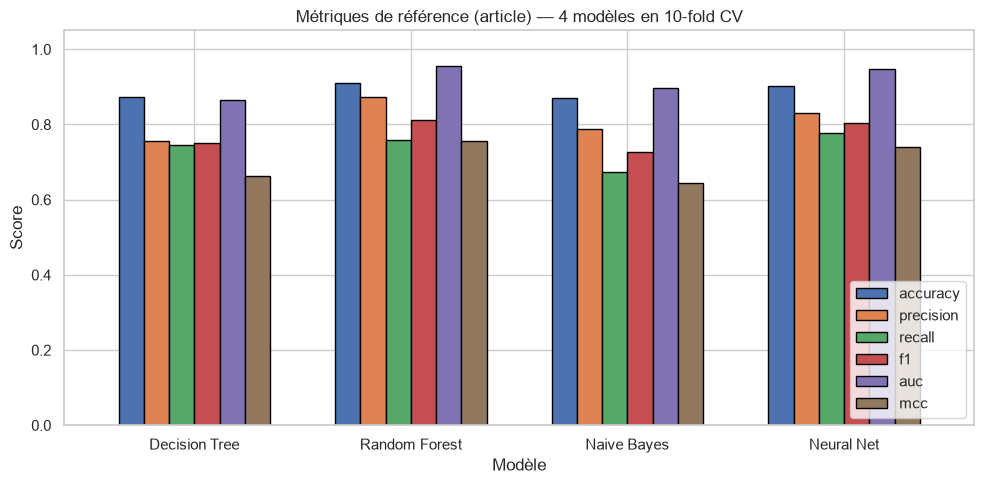


Cible à battre (RFC article) :
  accuracy     : 0.9100
  precision    : 0.8739
  recall       : 0.7598
  f1           : 0.8127
  auc          : 0.9551
  mcc          : 0.7572


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ref_df[['accuracy', 'precision', 'recall', 'f1', 'auc', 'mcc']].plot(
    kind='bar', ax=ax, edgecolor='black', width=0.7
)
ax.set_title('Métriques de référence (article) — 4 modèles en 10-fold CV')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print('\nCible à battre (RFC article) :')
rfc_ref = ref_df.loc['Random Forest']
for col in rfc_ref.index:
    print(f'  {col:12s} : {rfc_ref[col]:.4f}')

---
## 4. Modèle Word2Vec — `models/gensim/`

In [13]:
import os
gensim_dir = f'{ROOT}/models/gensim'
model_files = os.listdir(gensim_dir)
print('Fichiers dans models/gensim/ :', model_files)

# Décodage du nom : f2086855_mc1_W5_S64_samp0_a0.03_mina0.0007_n20_seed42_epoch5
# mc1   → min_count=1 (tous les tokens inclus)
# W5    → window=5
# S64   → vector_size=64
# n20   → negative=20
# seed42 → reproducibility
# epoch5 → 5 epochs
print()
print('Paramètres déduits du nom de fichier :')
print('  min_count  = 1')
print('  window     = 5')
print('  vector_size= 64')
print('  negative   = 20')
print('  seed       = 42')
print('  epochs     = 5')

Fichiers dans models/gensim/ : ['f2086855_mc1_W5_S64_samp0_a0.03_mina0.0007_n20_seed42_epoch5.model']

Paramètres déduits du nom de fichier :
  min_count  = 1
  window     = 5
  vector_size= 64
  negative   = 20
  seed       = 42
  epochs     = 5


In [14]:
# Le modèle a été entraîné avec un module custom 'tools' (callback) du repo original.
# Ce module n'est pas distribué → chargement impossible avec Word2Vec.load().
# Ce n'est pas bloquant : les features sont déjà pré-calculées dans data/input/.
try:
    from gensim.models import Word2Vec
    model_path = os.path.join(gensim_dir, model_files[0])
    w2v = Word2Vec.load(model_path)
    print(f'Vocab size  : {len(w2v.wv)}')
    print(f'Vector dim  : {w2v.wv.vector_size}')
except ModuleNotFoundError as e:
    print(f'[INFO] Chargement impossible : {e}')
    print('[INFO] Ce modèle requiert le module "tools" (callback custom des auteurs).')
    print('[INFO] → Non bloquant : X_train/X_test contiennent déjà les vecteurs calculés.')

[INFO] Chargement impossible : No module named 'tools'
[INFO] Ce modèle requiert le module "tools" (callback custom des auteurs).
[INFO] → Non bloquant : X_train/X_test contiennent déjà les vecteurs calculés.


---
## 5. `results/results_by_types.csv` — performances par règle squid

In [15]:
types_df = pd.read_csv(f'{ROOT}/results/results_by_types.csv')
print(f'Shape : {types_df.shape}')
print(f'Colonnes : {list(types_df.columns)}')
types_df.head(5)

Shape : (160, 9)
Colonnes : ['squid', 'tn', 'fp', 'tp', 'fn', 'accuracy', 'precision', 'recall', 'f1']


,squid,tn,fp,tp,fn,accuracy,precision,recall,f1
0,squid_S1067,0.200000,0.0,6.900000,0.0,1.000000,1.0,1.0,1.0
1,squid_S2225,0.333333,0.0,1.166667,0.0,1.000000,1.0,1.0,1.0
2,squid_S4201,0.400000,0.0,1.000000,0.0,1.000000,1.0,1.0,1.0
3,squid_S1215,0.200000,0.0,1.100000,0.0,1.000000,1.0,1.0,1.0
4,squid_S1155,217.900000,0.0,0.000000,0.3,0.998625,NaN,0.0,NaN


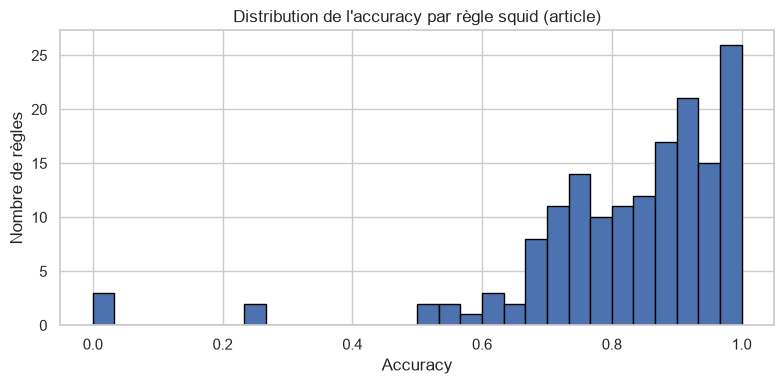

Règles avec accuracy = 1.0 : 4
Règles avec accuracy < 0.8 : 58

Règles les plus difficiles (accuracy < 0.8) :
                                     squid  accuracy        f1
98                             squid_S2272  0.789474       NaN
103   squid_AssignmentInSubExpressionCheck  0.794595  0.512821
104       squid_ForLoopCounterChangedCheck  0.793478  0.387097
105                            squid_S1151  0.789062  0.542373
106                            squid_S1943  0.782918  0.282353
107                            squid_S1185  0.783019  0.860606
108                            squid_S2142  0.776923  0.869955
109                            squid_S1192  0.773018  0.333959
110                            squid_S3599  0.625000  0.666667
111                            squid_S1301  0.765957       NaN
112                            squid_S1172  0.763359  0.863436
113                           squid_S00100  0.762376  0.813953
114                            squid_S1168  0.761905  0.848485
115     

In [16]:
# Distribution de l'accuracy par règle
fig, ax = plt.subplots(figsize=(8, 4))
types_df['accuracy'].plot(kind='hist', bins=30, ax=ax, edgecolor='black')
ax.set_title('Distribution de l\'accuracy par règle squid (article)')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Nombre de règles')
plt.tight_layout()
plt.show()

print(f'Règles avec accuracy = 1.0 : {(types_df["accuracy"] == 1.0).sum()}')
print(f'Règles avec accuracy < 0.8 : {(types_df["accuracy"] < 0.8).sum()}')
print(f'\nRègles les plus difficiles (accuracy < 0.8) :')
print(types_df[types_df['accuracy'] < 0.8][['squid', 'accuracy', 'f1']].to_string())

---
## 6. Récapitulatif

| Élément | Valeur |
|---|---|
| `main_dataset.csv` | 224 484 instances × 12 colonnes |
| Règles SonarQube | 160 règles uniques (`squid`) |
| Distribution brute | cls=0 (TP) 20.9 % / cls=1 (FP) 79.1 % |
| Split `input/` | train 39 263 + test 4 433 = 43 696 instances |
| Dimensions features | 480 = 160 one-hot squid + 5×64 W2V |
| Distribution input/ | cls=0 ≈74 % / cls=1 ≈26 % (sous-ensemble filtré) |
| RFC article (10-fold) | Acc 0.910 / F1 0.813 / AUC 0.955 |
| Word2Vec | 64 dims, window=5, min_count=1, seed=42 — **non chargeable** (module `tools` manquant) |

**Conclusion** : les features sont prêtes dans `data/input/`. Le notebook `02_features.ipynb` servira uniquement à valider ce split et à sauvegarder X/y en format `.npy` pour accélerer le chargement dans les notebooks suivants.